In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import pickle

In [2]:

ds_name = 'markov_32feat_11t5g_less_balanced'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_Markov_imbalanced'
g_resol = 1
model_prefix = 'Joint'

DIR_MODEL_SAVE = os.path.join('sksurv_models', project, model_prefix)

if os.path.exists(DIR_MODEL_SAVE):
    shutil.rmtree(DIR_MODEL_SAVE)
    os.mkdir(DIR_MODEL_SAVE)
else:
    os.mkdir(DIR_MODEL_SAVE)

In [3]:
from dataset_11t5g_markov import DatasetMarkovSurvSurf

ds_train = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='train', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
ds_val = DatasetMarkovSurvSurf(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split='val', 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)


In [4]:
df_Xy_train = ds_train._get_df_Xy_trans_obs()
assert all(
    df_Xy_train.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_train['event_observed'] = df_Xy_train['event_observed'].astype(bool)
df_Xy_train = df_Xy_train.sort_values('subject')

df_Xy_val = ds_val._get_df_Xy_trans_obs()
assert all(
    df_Xy_val.groupby(ds_train.colname_g)['subject'].apply(lambda x: x.value_counts().max() == 1)
)
df_Xy_val = df_Xy_val.sort_values('subject')
df_Xy_val['event_observed'] = df_Xy_val['event_observed'].astype(bool)

df_Xy_val_grid = ds_val._get_df_Xy_true_prob()
df_Xy_val_grid = df_Xy_val_grid.sort_values(['subject',ds_train.colname_g])
df_Xy_val_grid['event_observed'] = df_Xy_val_grid['event_observed'].astype(bool)


In [5]:
df_Xy_train.head()

,subject,event_observed,duration,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
0,0,False,8,1.0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,...,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-0.885493,0.0,1,1
1,2,True,2,1.0,1.301429,-0.994802,2.094665,0.359429,0.691002,-1.485720,...,-0.938910,-1.901464,1.095433,-0.333544,-1.441849,-1.416667,-1.629502,0.0,1,1
2,2,False,9,2.0,1.301429,-0.994802,2.094665,0.359429,0.691002,-1.485720,...,-0.938910,-1.901464,1.095433,-0.333544,-1.441849,-1.416667,-1.629502,0.0,1,1
3,4,False,10,1.0,-0.105813,2.009902,0.011231,-1.089429,-1.514511,-0.559761,...,-1.941266,0.341435,1.862855,-0.295230,0.478317,-0.715190,1.237293,1.0,1,1
4,6,True,7,1.0,0.805669,-0.012551,-0.260823,-0.889478,-1.615899,-0.851965,...,-0.708124,1.414139,-0.490533,1.181171,-0.046925,-1.460106,-0.508191,0.0,1,1


In [6]:
cols_y = ['event_observed', 'duration']
cols_X = np.r_[[ds_train.colname_g], df_Xy_train.columns[df_Xy_train.columns.str.startswith('feat')]]

In [7]:
cols_y

['event_observed', 'duration']

In [8]:
cols_X

array(['g_max_by_time', 'feat00', 'feat01', 'feat02', 'feat03', 'feat04',
       'feat05', 'feat06', 'feat07', 'feat08', 'feat09', 'feat10',
       'feat11', 'feat12', 'feat13', 'feat14', 'feat15', 'feat16',
       'feat17', 'feat18', 'feat19', 'feat20', 'feat21', 'feat22',
       'feat23', 'feat24', 'feat25', 'feat26', 'feat27', 'feat28',
       'feat29', 'feat30', 'feat31'], dtype=object)

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
def get_non_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(n_jobs=n_jobs, random_state=random_state, min_samples_leaf=3, n_estimators=1000)
        except TypeError:
            return model_class(random_state=random_state, min_samples_leaf=10, n_estimators=50)
    return get_model

def get_cox_model(model_class):
    def get_model(n_jobs, random_state):
        try:
            return model_class(fit_baseline_model=True, ties='efron')
        except TypeError:
            try:
                return model_class(fit_baseline_model=True)
            except TypeError:
                return model_class()
    return get_model

model_name_to_class = {
    f'{model_prefix}_{GradientBoostingSurvivalAnalysis.__name__}':get_non_cox_model(GradientBoostingSurvivalAnalysis),
    f'{model_prefix}_{RandomSurvivalForest.__name__}':get_non_cox_model(RandomSurvivalForest),
    f'{model_prefix}_{CoxnetSurvivalAnalysis.__name__}':get_cox_model(CoxnetSurvivalAnalysis),
    f'{model_prefix}_{CoxPHSurvivalAnalysis.__name__}':get_cox_model(CoxPHSurvivalAnalysis),
}

In [10]:
df_metrics = []
surv_funcs = dict()
event_to_model = dict()
seeds = [10,20,30,40,50]
for model_name, model_class in model_name_to_class.items():
    for seed in seeds:
        model_id = f'{model_name}_seed_{seed}'
        model = model_class(n_jobs=-1, random_state=seed)
        y = df_Xy_train[cols_y].to_records(index=False)
        X = df_Xy_train[cols_X]
        model.fit(X, y)

        model_path = os.path.join(DIR_MODEL_SAVE,f'{model_id}.pickle')
        with open(model_path, 'wb') as f:
            # Pickle the 'data' dictionary using the highest protocol available.
            pickle.dump(model, f)

        for g, df_train_sub in df_Xy_train.groupby(ds_train.colname_g):
            if all(df_train_sub['event_observed'] == 0):
                continue
            
            y = df_train_sub[cols_y].to_records(index=False)
            X = df_train_sub[cols_X]
            event_to_model[f'{model_id}_event_{g}'] = model
            record = {
                'model_name':model_name,
                'event':g,
                'seed':seed,
                'c_index_train':model.score(X,y)
            }

            df_val_sub = df_Xy_val.loc[
                df_Xy_val[ds_train.colname_g] == g,:
            ]
            y = df_val_sub[cols_y].to_records(index=False)
            X = df_val_sub[cols_X]
            record['c_index_val'] = model.score(X,y)
            df_metrics.append(record)

            df_val_sub = df_Xy_val_grid.loc[
                df_Xy_val_grid[ds_train.colname_g] == g,:
            ].drop(columns=['duration','event_observed']).drop_duplicates().sort_values('subject')
            X = df_val_sub[cols_X]

            surv_funcs[f'{model_id}_event_{g}'] = model.predict_survival_function(X=X)
        print(f'finished running model {model_name}')
df_metrics = pd.DataFrame(df_metrics)


finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_GradientBoostingSurvivalAnalysis
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_RandomSurvivalForest
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxnetSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Joint_CoxPHSurvivalAnalysis
finished running model Join

In [11]:
df_val_sub

,subject,g_max_by_time,feat00,feat01,feat02,feat03,feat04,feat05,feat06,feat07,...,feat24,feat25,feat26,feat27,feat28,feat29,feat30,feat31,weight,is_t_trans
2,3,3,-1.056169,0.554275,-0.950018,0.857999,-0.532079,1.125759,0.218658,-0.392882,...,0.289559,-0.470209,1.605993,-0.153662,-1.786169,-0.111657,1.537644,0.0,1,NaN
7,7,3,0.761786,-1.646844,0.853926,-0.007960,-0.889475,0.353508,-0.539431,0.591133,...,0.143467,1.434845,1.055364,1.115293,1.801006,-0.194419,-0.842187,0.0,1,NaN
12,15,3,1.905088,0.952670,-0.432973,-0.730569,-1.093725,0.437599,-0.761883,-1.029683,...,-1.071806,1.491680,-0.412008,1.125530,0.298597,0.380416,-0.360827,0.0,1,NaN
17,17,3,-0.851021,0.382710,-2.104251,0.611296,0.334314,1.881421,-0.924426,-0.457373,...,0.820551,0.305156,-1.235898,0.832217,0.382172,-0.732978,0.506060,0.0,1,NaN
22,19,3,0.287647,1.635691,0.114950,0.176676,-0.271338,-0.748332,-0.812047,0.759777,...,0.149182,-0.036294,0.197549,0.526756,-1.869619,0.469936,-0.386902,1.0,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2477,1985,3,-0.930535,-0.669600,1.791801,-0.459592,-1.354114,-0.381892,0.153283,2.433270,...,-0.698778,1.069577,2.513857,-0.175994,-0.545026,-0.705365,-1.184941,0.0,1,NaN
2482,1987,3,0.616676,-0.871592,0.610766,-0.067604,0.812099,0.539699,-1.080430,-2.755128,...,0.435016,0.826654,-0.133526,0.689951,0.509071,-0.241583,-1.180800,1.0,1,NaN
2487,1989,3,0.814830,-0.953818,-1.002373,0.312133,-0.711412,-0.600434,0.607461,-0.361851,...,-1.717239,-0.078058,-1.327853,0.200621,-1.224429,-0.420712,0.430444,1.0,1,NaN
2492,1991,3,-0.048159,0.158154,0.991666,-0.793758,-1.262142,-1.117240,0.041638,2.238971,...,-1.395065,-0.478450,-0.731282,0.438083,-0.167460,1.138801,1.433848,0.0,1,NaN


In [12]:
df_metrics.groupby(['model_name','event'])['c_index_val'].describe()

count      mean       std  \
model_name                             event                              
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.772527  0.000000   
                                       2.0      5.0  0.678968  0.000000   
                                       3.0      5.0  0.211538  0.000000   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  0.772600  0.000000   
                                       2.0      5.0  0.678391  0.000000   
                                       3.0      5.0  0.211538  0.000000   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.694280  0.000000   
                                       2.0      5.0  0.624477  0.000000   
                                       3.0      5.0  0.346154  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.734283  0.002077   
                                       2.0      5.0  0.722618  0.008589   
                                       3.0      5.0  0.297115  0.059701   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.772527  0.772527  0.772527   
                                       2.0    0.678968  0.678968  0.678968   
                                       3.0    0.211538  0.211538  0.211538   
Joint_CoxnetSurvivalAnalysis           1.0    0.772600  0.772600  0.772600   
                                       2.0    0.678391  0.678391  0.678391   
                                       3.0    0.211538  0.211538  0.211538   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.694280  0.694280  0.694280   
                                       2.0    0.624477  0.624477  0.624477   
                                       3.0    0.346154  0.346154  0.346154   
Joint_RandomSurvivalForest             1.0    0.731509  0.733542  0.734025   
                                       2.0    0.715583  0.716592  0.717457   
                                       3.0    0.197115  0.298077  0.317308   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.772527  0.772527  
                                       2.0    0.678968  0.678968  
                                       3.0    0.211538  0.211538  
Joint_CoxnetSurvivalAnalysis           1.0    0.772600  0.772600  
                                       2.0    0.678391  0.678391  
                                       3.0    0.211538  0.211538  
Joint_GradientBoostingSurvivalAnalysis 1.0    0.694280  0.694280  
                                       2.0    0.624477  0.624477  
                                       3.0    0.346154  0.346154  
Joint_RandomSurvivalForest             1.0    0.735216  0.737125  
                                       2.0    0.728845  0.734612  
                                       3.0    0.317308  0.355769

In [13]:
df = df_metrics.copy()
df['val_as_frac_of_train'] = df_metrics['c_index_val']/df_metrics['c_index_train']
df.groupby(['model_name','event'])['val_as_frac_of_train'].describe()

count      mean       std  \
model_name                             event                              
Joint_CoxPHSurvivalAnalysis            1.0      5.0  0.966562  0.000000   
                                       2.0      5.0  1.064828  0.000000   
                                       3.0      5.0  0.297571  0.000000   
Joint_CoxnetSurvivalAnalysis           1.0      5.0  0.966490  0.000000   
                                       2.0      5.0  1.065613  0.000000   
                                       3.0      5.0  0.297571  0.000000   
Joint_GradientBoostingSurvivalAnalysis 1.0      5.0  0.872638  0.000000   
                                       2.0      5.0  0.745381  0.000000   
                                       3.0      5.0  0.513986  0.000000   
Joint_RandomSurvivalForest             1.0      5.0  0.759500  0.001859   
                                       2.0      5.0  0.733845  0.008708   
                                       3.0      5.0  0.405398  0.083552   

                                                   min       25%       50%  \
model_name                             event                                 
Joint_CoxPHSurvivalAnalysis            1.0    0.966562  0.966562  0.966562   
                                       2.0    1.064828  1.064828  1.064828   
                                       3.0    0.297571  0.297571  0.297571   
Joint_CoxnetSurvivalAnalysis           1.0    0.966490  0.966490  0.966490   
                                       2.0    1.065613  1.065613  1.065613   
                                       3.0    0.297571  0.297571  0.297571   
Joint_GradientBoostingSurvivalAnalysis 1.0    0.872638  0.872638  0.872638   
                                       2.0    0.745381  0.745381  0.745381   
                                       3.0    0.513986  0.513986  0.513986   
Joint_RandomSurvivalForest             1.0    0.757086  0.758634  0.759258   
                                       2.0    0.726398  0.727174  0.729572   
                                       3.0    0.270803  0.405716  0.424038   

                                                   75%       max  
model_name                             event                      
Joint_CoxPHSurvivalAnalysis            1.0    0.966562  0.966562  
                                       2.0    1.064828  1.064828  
                                       3.0    0.297571  0.297571  
Joint_CoxnetSurvivalAnalysis           1.0    0.966490  0.966490  
                                       2.0    1.065613  1.065613  
                                       3.0    0.297571  0.297571  
Joint_GradientBoostingSurvivalAnalysis 1.0    0.872638  0.872638  
                                       2.0    0.745381  0.745381  
                                       3.0    0.513986  0.513986  
Joint_RandomSurvivalForest             1.0    0.760559  0.761962  
                                       2.0    0.740215  0.745867  
                                       3.0    0.425975  0.500460

([0, 1, 2, 3],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest'),
  Text(2, 0, 'Joint_CoxnetSurvivalAnalysis'),
  Text(3, 0, 'Joint_CoxPHSurvivalAnalysis')])

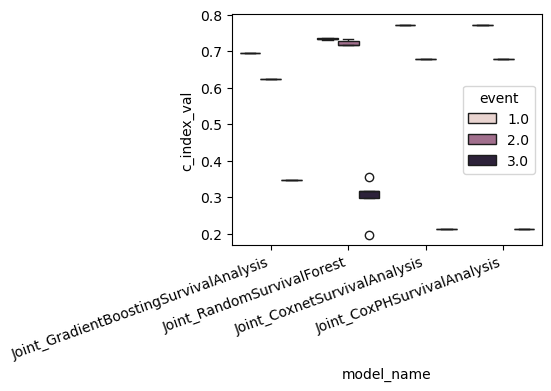

In [14]:
fig, ax = plt.subplots(1,1, figsize=(4, 3))
sns.boxplot(
    data=df_metrics,
    x='model_name',
    y='c_index_val',
    hue='event',
    ax=ax,
)
plt.xticks(rotation=20, ha='right')


In [15]:
n_curves_per_model = [len(i) for i in surv_funcs.values()]

n_curves_per_model = n_curves_per_model[0]

In [16]:
list(surv_funcs.keys())

['Joint_GradientBoostingSurvivalAnalysis_seed_10_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_10_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_20_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_30_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_40_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_40_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_40_event_3.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_50_event_1.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_50_event_2.0',
 'Joint_GradientBoostingSurvivalAnalysis_seed_50_event_3.0',
 'Joint_RandomSurvivalForest_seed_10_event_1.0',
 'Joint_RandomSurvivalForest_seed_10

In [17]:
df_is_event1_higher_prob = []
for model_name in model_name_to_class.keys():
    for seed in seeds:
        for subj_index in range(n_curves_per_model):
            for g in sorted(df_metrics['event'].unique())[:-1]:
                curve_event1 = surv_funcs[f'{model_name}_seed_{seed}_event_{g}'][subj_index]
                curve_event2 = surv_funcs[f'{model_name}_seed_{seed}_event_{g+1}'][subj_index]

                x_interp = list(set(curve_event1.x).union(curve_event2.x))
                x_interp = sorted(x_interp)
                y_interp_event1 = curve_event1(x_interp)
                y_interp_event2 = curve_event2(x_interp)

                prop_t_event1_higher_prob = np.mean(y_interp_event2 < y_interp_event1)
                row = {
                    'model_name':model_name,
                    'seed': seed,
                    'subj_index':subj_index,
                    'subj':df_Xy_val_grid['subject'].drop_duplicates().sort_values().iloc[subj_index],
                    'prop_t_event1_higher_prob':prop_t_event1_higher_prob,
                    'g':g
                }
                df_is_event1_higher_prob.append(row)
df_is_event1_higher_prob = pd.DataFrame(df_is_event1_higher_prob)


In [18]:
df_is_event1_higher_prob.head()

,model_name,seed,subj_index,subj,prop_t_event1_higher_prob,g
0,Joint_GradientBoostingSurvivalAnalysis,10,0,3,0.0,1.0
1,Joint_GradientBoostingSurvivalAnalysis,10,0,3,0.0,2.0
2,Joint_GradientBoostingSurvivalAnalysis,10,1,7,0.0,1.0
3,Joint_GradientBoostingSurvivalAnalysis,10,1,7,0.0,2.0
4,Joint_GradientBoostingSurvivalAnalysis,10,2,15,0.0,1.0


([0, 1, 2, 3],
 [Text(0, 0, 'Joint_GradientBoostingSurvivalAnalysis'),
  Text(1, 0, 'Joint_RandomSurvivalForest'),
  Text(2, 0, 'Joint_CoxnetSurvivalAnalysis'),
  Text(3, 0, 'Joint_CoxPHSurvivalAnalysis')])

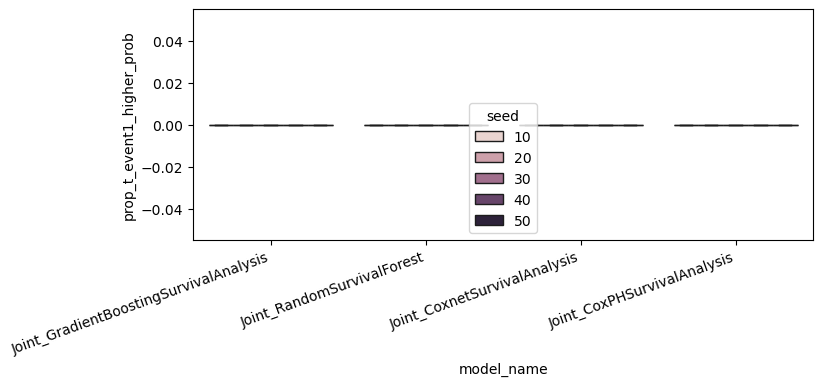

In [19]:
fig, ax = plt.subplots(1,1, figsize=(8, 3))
sns.boxplot(
    data=df_is_event1_higher_prob,
    x='model_name',
    y='prop_t_event1_higher_prob',
    hue='seed',
    ax=ax,
    showfliers=False
)
plt.xticks(rotation=20, ha='right')



In [20]:
df_is_event1_higher_prob.groupby(['model_name','seed'])['prop_t_event1_higher_prob'].describe()

count    mean       std  min  \
model_name                             seed                                  
Joint_CoxPHSurvivalAnalysis            10    1000.0  0.0000  0.000000  0.0   
                                       20    1000.0  0.0000  0.000000  0.0   
                                       30    1000.0  0.0000  0.000000  0.0   
                                       40    1000.0  0.0000  0.000000  0.0   
                                       50    1000.0  0.0000  0.000000  0.0   
Joint_CoxnetSurvivalAnalysis           10    1000.0  0.0000  0.000000  0.0   
                                       20    1000.0  0.0000  0.000000  0.0   
                                       30    1000.0  0.0000  0.000000  0.0   
                                       40    1000.0  0.0000  0.000000  0.0   
                                       50    1000.0  0.0000  0.000000  0.0   
Joint_GradientBoostingSurvivalAnalysis 10    1000.0  0.0130  0.113331  0.0   
                                       20    1000.0  0.0130  0.113331  0.0   
                                       30    1000.0  0.0130  0.113331  0.0   
                                       40    1000.0  0.0130  0.113331  0.0   
                                       50    1000.0  0.0130  0.113331  0.0   
Joint_RandomSurvivalForest             10    1000.0  0.0030  0.038373  0.0   
                                       20    1000.0  0.0035  0.043355  0.0   
                                       30    1000.0  0.0034  0.043708  0.0   
                                       40    1000.0  0.0037  0.044478  0.0   
                                       50    1000.0  0.0024  0.033096  0.0   

                                             25%  50%  75%  max  
model_name                             seed                      
Joint_CoxPHSurvivalAnalysis            10    0.0  0.0  0.0  0.0  
                                       20    0.0  0.0  0.0  0.0  
                                       30    0.0  0.0  0.0  0.0  
                                       40    0.0  0.0  0.0  0.0  
                                       50    0.0  0.0  0.0  0.0  
Joint_CoxnetSurvivalAnalysis           10    0.0  0.0  0.0  0.0  
                                       20    0.0  0.0  0.0  0.0  
                                       30    0.0  0.0  0.0  0.0  
                                       40    0.0  0.0  0.0  0.0  
                                       50    0.0  0.0  0.0  0.0  
Joint_GradientBoostingSurvivalAnalysis 10    0.0  0.0  0.0  1.0  
                                       20    0.0  0.0  0.0  1.0  
                                       30    0.0  0.0  0.0  1.0  
                                       40    0.0  0.0  0.0  1.0  
                                       50    0.0  0.0  0.0  1.0  
Joint_RandomSurvivalForest             10    0.0  0.0  0.0  0.8  
                                       20    0.0  0.0  0.0  0.9  
                                       30    0.0  0.0  0.0  0.7  
                                       40    0.0  0.0  0.0  0.9  
                                       50    0.0  0.0  0.0  0.7

In [21]:
df_attention = df_is_event1_higher_prob.loc[df_is_event1_higher_prob['prop_t_event1_higher_prob'] > 0.02,:]
df_attention

,model_name,seed,subj_index,subj,prop_t_event1_higher_prob,g
184,Joint_GradientBoostingSurvivalAnalysis,10,92,375,1.0,1.0
218,Joint_GradientBoostingSurvivalAnalysis,10,109,451,1.0,1.0
278,Joint_GradientBoostingSurvivalAnalysis,10,139,593,1.0,1.0
284,Joint_GradientBoostingSurvivalAnalysis,10,142,601,1.0,1.0
358,Joint_GradientBoostingSurvivalAnalysis,10,179,709,1.0,1.0
...,...,...,...,...,...,...
9440,Joint_RandomSurvivalForest,50,220,887,0.7,1.0
9591,Joint_RandomSurvivalForest,50,295,1143,0.1,2.0
9642,Joint_RandomSurvivalForest,50,321,1223,0.4,1.0
9781,Joint_RandomSurvivalForest,50,390,1529,0.1,2.0
